In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
# https://www.hpcf.upr.edu/~abel/phl/hwc/data/hwc.csv
df = pd.read_csv(r'C:\Users\ryanh\OneDrive\Documents\GitHub\Exo-planet-Analysis\Notebooks\Datasets\Habitable_worlds_full_dataset_ADJUSTED.csv')
pd.set_option('display.max_colwidth', None) #Remove limitation of column width
pd.set_option('display.max_columns', None) #Remove limitation of columns displayed
pd.set_option('display.max_rows', None) #Remove limitation of rows displayed

In [53]:
df2 = df.dropna(subset=['S_TYPE_TEMP'], inplace=False) # Drop rows where 'S_TYPE_TEMP' is NaN
df2 = df2[df2['S_TYPE_TEMP'].isin(['M','K','G'])] # Filter the dataset to keep only rows where 'S_TYPE_TEMP' is 'M', 'K', or 'G'
df2 = df2[df2['P_ESI'] > 0.5] # Filter the dataset to keep only rows where 'P_ESI' is greater than 0.5
df2 = df2[~df2['S_TYPE_TEMP'].isin(['PSR','WD','BD'])] # Filter the dataset to remove rows where 'S_TYPE_TEMP' is 'PSR', 'WD', or 'BD'
df2.fillna({'P_GRAVITY': df2['P_GRAVITY'].median(),
            'P_PERIOD': df2['P_PERIOD'].median(),
            'P_RADIUS': df2['P_RADIUS'].median(),
            'P_MASS': df2['P_MASS'].median(),
            'P_DENSITY': df2['P_DENSITY'].median(),
            'P_DISTANCE': df2['P_DISTANCE'].median(), 
            'P_FLUX': df2['P_FLUX'].median(),
            'P_TEMP_EQUIL': df2['P_TEMP_EQUIL'].median(),
            'P_HABITABLE': 0
            }, inplace=True) # Fill remaining NaN values for the planetary parameters with the median of each column
df2['P_HABITABLE'] = df2['P_HABITABLE'].map({0: 0, 1: 1, 2: 1}) # Create a new column 'Habitable' where 1 indicates habitable and 0 indicates non-habitable
print(df2.isnull().sum())
print(df2.info()) 

P_NAME            0
P_MASS            0
P_RADIUS          0
P_PERIOD          0
P_GRAVITY         0
P_DENSITY         0
P_DISTANCE        0
P_FLUX            0
P_TEMP_EQUIL      0
P_TEMP_SURF      67
P_TYPE            0
P_TYPE_TEMP       0
S_NAME            0
S_TYPE_TEMP       0
S_RA              0
S_DEC             0
S_MAG             1
S_TEMPERATURE     0
S_MASS            0
S_RADIUS          0
S_METALLICITY    18
S_LUMINOSITY      0
S_HZ_OPT_MIN      0
S_HZ_OPT_MAX      0
S_HZ_CON_MIN      0
S_HZ_CON_MAX      0
S_SNOW_LINE       0
S_ABIO_ZONE       0
P_HABZONE_OPT     0
P_HABZONE_CON     0
P_HABITABLE       0
P_ESI             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 252 entries, 36 to 5581
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         252 non-null    object 
 1   P_MASS         252 non-null    float64
 2   P_RADIUS       252 non-null    float64
 3   P_PERIOD       252 n

C:\Users\ryanh\AppData\Local\Temp\ipykernel_29524\1767849153.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type


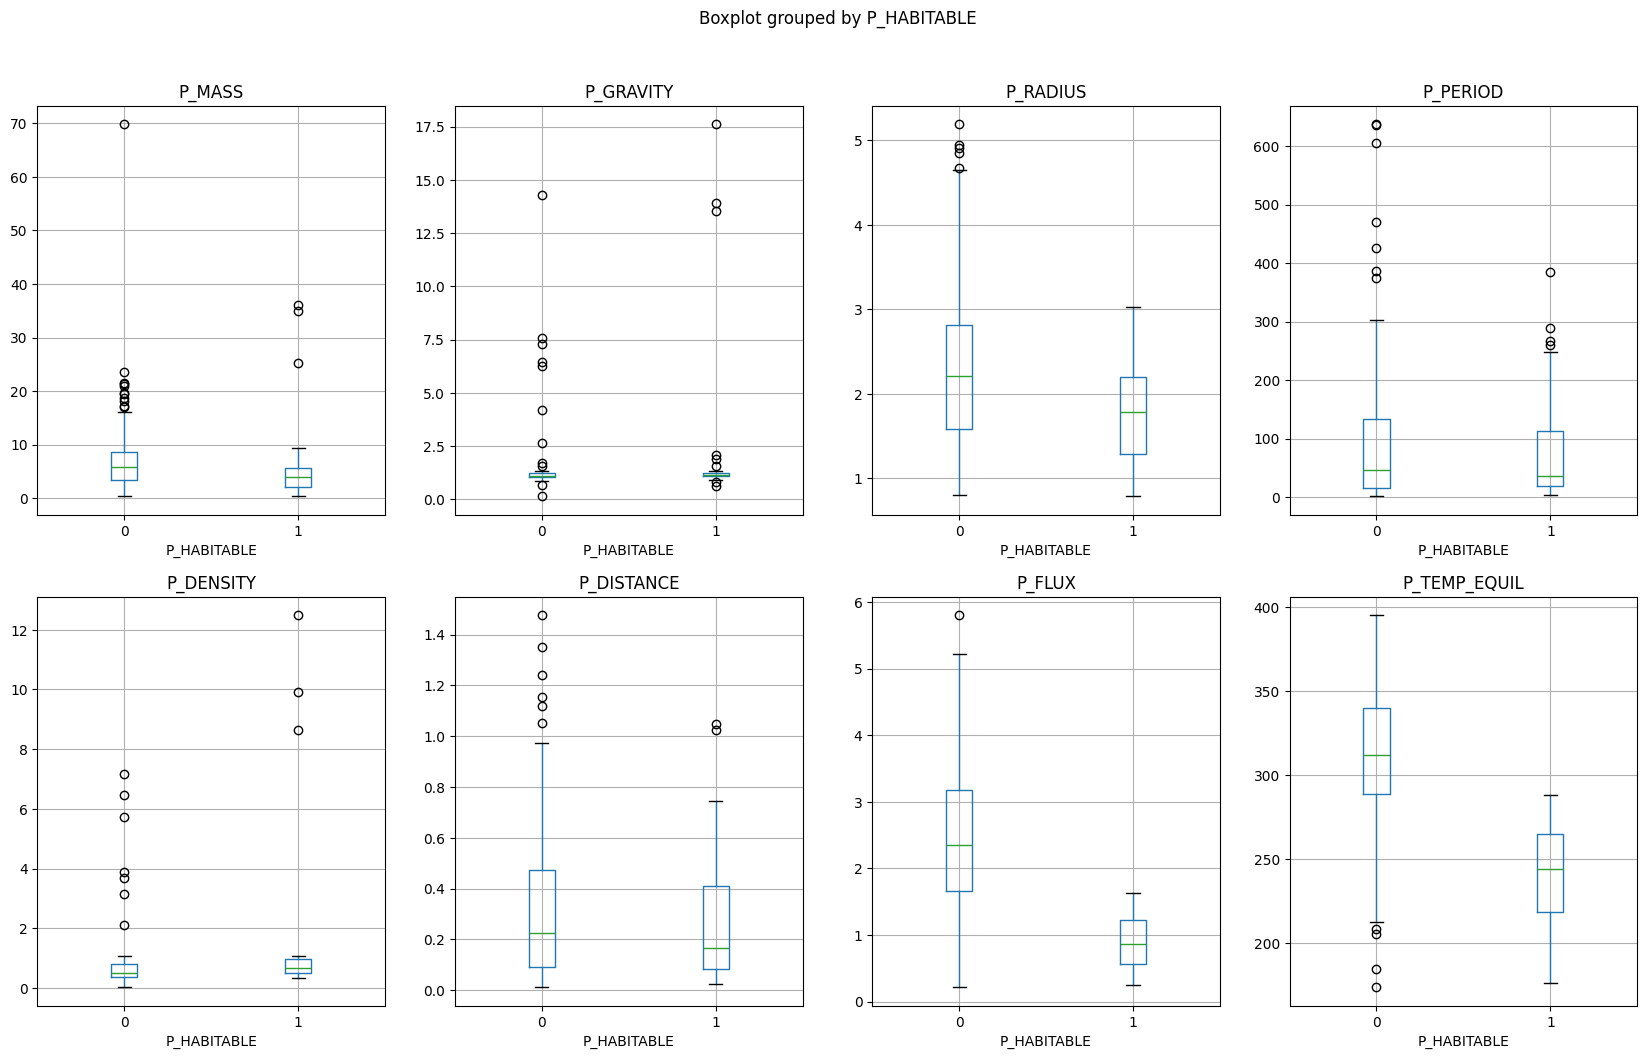

In [54]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=True) # Create boxplots for each planetary parameter grouped by stellar type

C:\Users\ryanh\AppData\Local\Temp\ipykernel_29524\4237270406.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot2 = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers


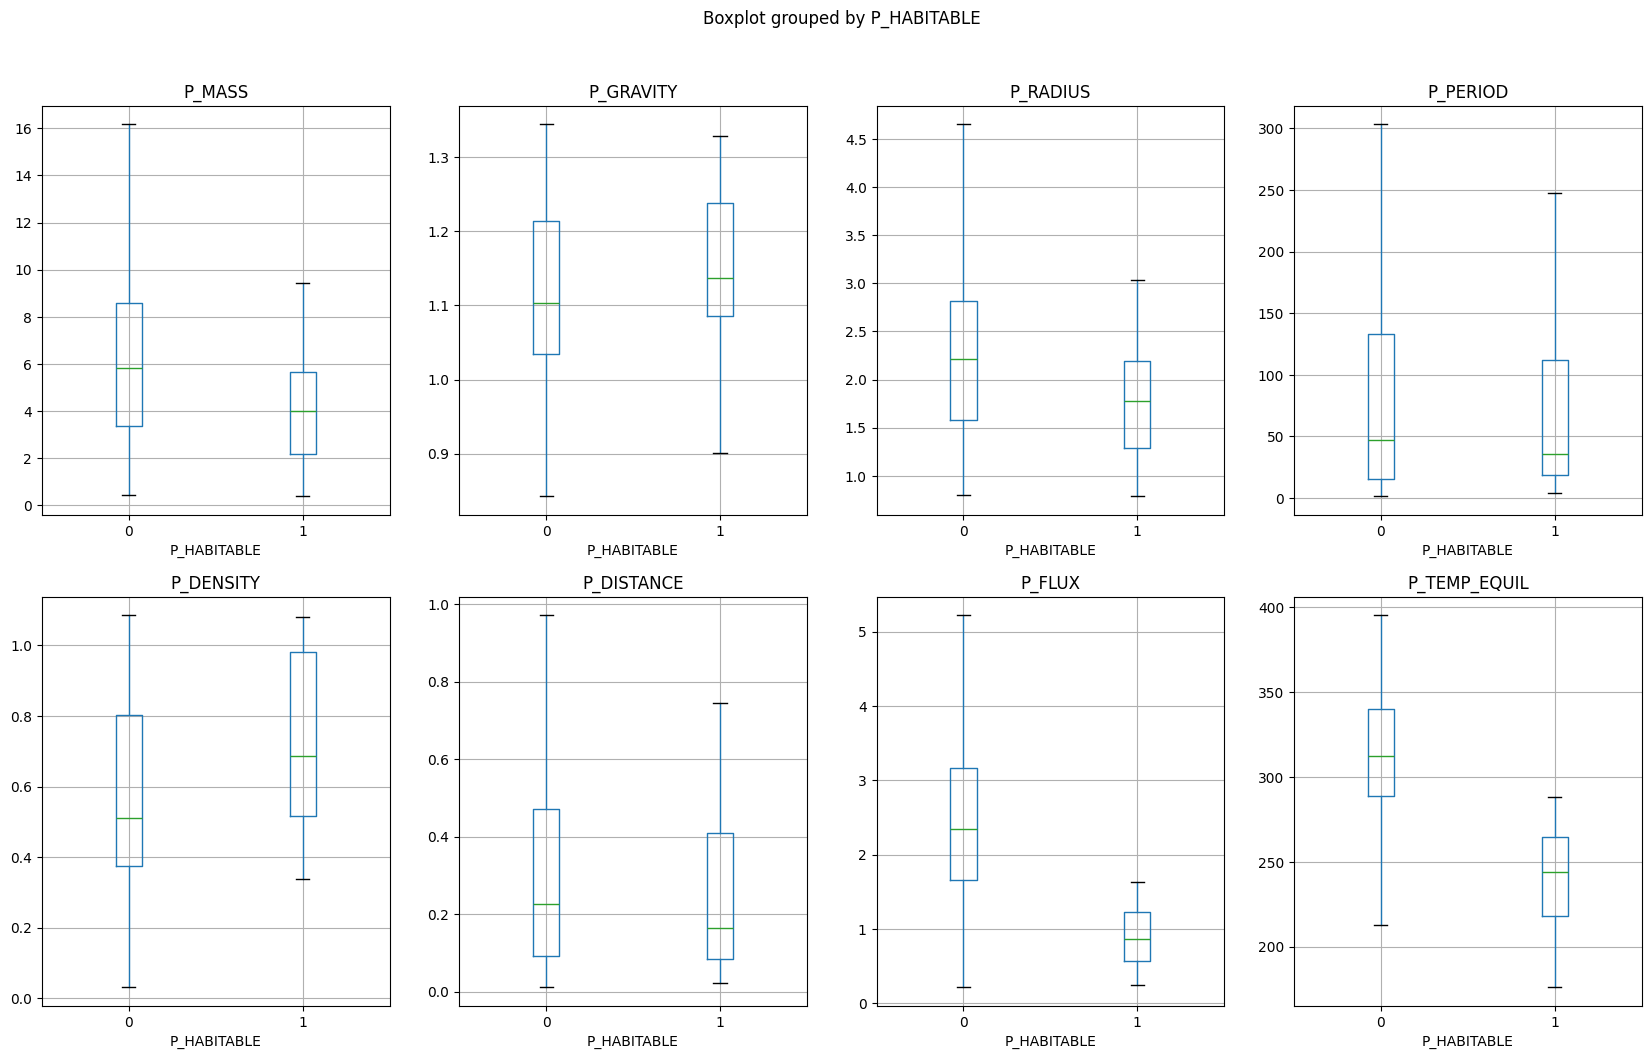

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(20, 12), sharey=False) # Create subplots for each group of habitable planets
boxplot2 = df2.boxplot(column=['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers

C:\Users\ryanh\AppData\Local\Temp\ipykernel_29524\871534816.py:2: UserWarning: When passing multiple axes, sharex and sharey are ignored. These settings must be specified when creating axes.
  boxplot2 = df2.boxplot(column=['P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers


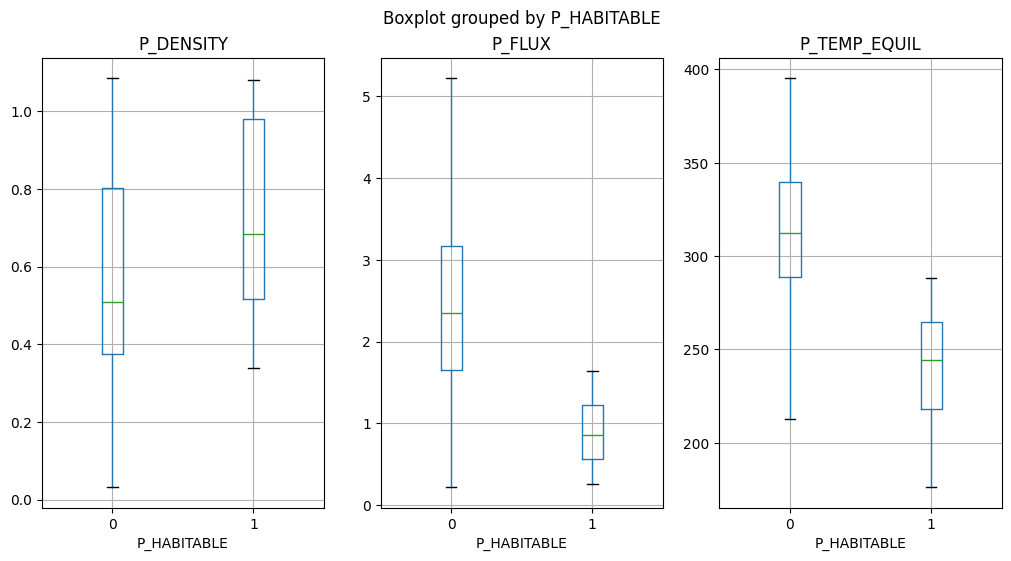

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6), sharey=False) # Create subplots for each group of habitable planets
boxplot2 = df2.boxplot(column=['P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL'], by = 'P_HABITABLE', ax=axs, showfliers=False) # Create boxplots for each planetary parameter grouped by stellar type without outliers

Principle Component Analysis

In [57]:
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

df2.columns

Index(['P_NAME', 'P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_GRAVITY', 'P_DENSITY',
       'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TEMP_SURF', 'P_TYPE',
       'P_TYPE_TEMP', 'S_NAME', 'S_TYPE_TEMP', 'S_RA', 'S_DEC', 'S_MAG',
       'S_TEMPERATURE', 'S_MASS', 'S_RADIUS', 'S_METALLICITY', 'S_LUMINOSITY',
       'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX',
       'S_SNOW_LINE', 'S_ABIO_ZONE', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_HABITABLE', 'P_ESI'],
      dtype='object')

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets

In [59]:
X_train_pca = scaleStandard.fit_transform(X_train_pca) # Fit the scaler to the training data and transform it
X_train_pca = pd.DataFrame(X_train_pca, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame

X_train_pca.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,201.000,201.000,201.000,201.000,201.000,201.000,201.000,201.000
mean,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,-0.880,-1.614,-0.789,-0.433,-0.500,-1.050,-1.439,-2.250
25%,-0.532,-0.772,-0.643,-0.225,-0.333,-0.759,-0.772,-0.666
50%,-0.185,-0.041,-0.427,-0.187,-0.205,-0.397,-0.203,0.050
75%,0.184,0.663,0.416,-0.142,0.003,0.646,0.623,0.733
max,9.355,3.490,5.570,7.869,8.278,4.187,3.023,2.036


In [60]:
pca1 = PCA()
X_pca1 = pca1.fit_transform(X_train_pca) # Fit PCA to the scaled training data and transform it
pca1.explained_variance_ratio_

array([0.38941636, 0.30985845, 0.17653061, 0.10240651, 0.01358102,
       0.00474808, 0.00274287, 0.00071611])

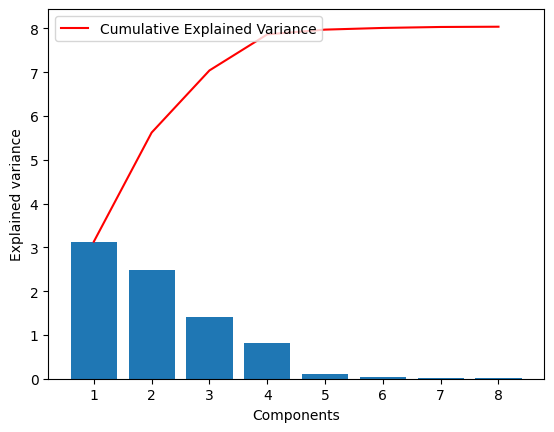

In [61]:
plt.bar(range(1,len(pca1.explained_variance_ )+1),pca1.explained_variance_ )
plt.ylabel('Explained variance')
plt.xlabel('Components')
plt.plot(range(1,len(pca1.explained_variance_ )+1),
         np.cumsum(pca1.explained_variance_),
         c='red',
         label="Cumulative Explained Variance")
plt.legend(loc='upper left')

In [62]:
pca2 = PCA(0.90) # Create a PCA object that retains 90% of the variance
X_pca2 = pca2.fit_transform(X_train_pca) # Fit PCA to the scaled data
X_pca2.shape # Display the shape of the transformed data

(201, 4)

In [63]:
pca2c = PCA(n_components=2) # Create a PCA object that retains 2 components
X_pca2c = pca2c.fit_transform(X_train_pca) # Fit PCA to the scaled training data and transform it to 2 components

In [64]:
colormap = plt.colormaps.get_cmap('coolwarm') # Define a colormap for the scatter plot
encoded_y_train = pd.Series(y_train_pca).astype('category').cat.codes # Encode the categorical target variable for coloring

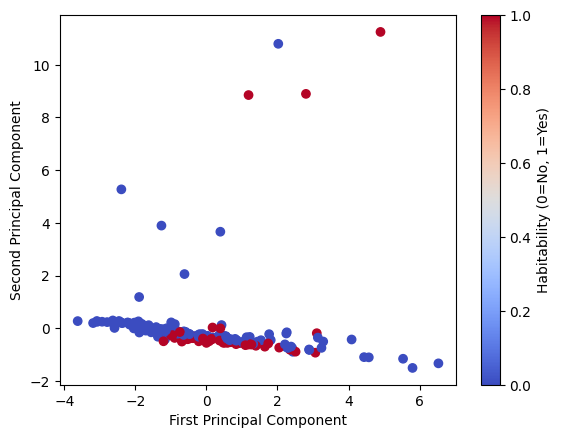

In [65]:
plt.figure()
ax = plt.gca()
scatter = plt.scatter(X_pca2c[:, 0], X_pca2c[:, 1], c=encoded_y_train, cmap=colormap) # Create a scatter plot of the first two principal components colored by stellar type
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter, label='Habitability (0=No, 1=Yes)') # Add a colorbar to indicate the stellar type
plt.show()

Linear Discriminant Analysis

In [66]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [67]:
scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

X = scaleStandard.fit_transform(X) # Fit the scaler to the training data and transform it
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets
X_train_lda = pd.DataFrame(X_train_lda, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame
X_test_lda = pd.DataFrame(X_test_lda, columns=df2.columns[1:9]) # Convert the scaled testing data back to a DataFrame

X_train_lda.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,201.000,201.000,201.000,201.000,201.000,201.000,201.000,201.000
mean,-0.036,-0.107,-0.054,0.032,0.041,-0.062,0.009,-0.002
std,1.043,0.915,0.957,1.093,1.079,0.944,1.019,1.024
min,-0.952,-1.579,-0.807,-0.440,-0.497,-1.051,-1.453,-2.300
25%,-0.590,-0.811,-0.668,-0.213,-0.317,-0.778,-0.775,-0.682
50%,-0.229,-0.144,-0.462,-0.172,-0.179,-0.437,-0.197,0.049
75%,0.155,0.498,0.343,-0.122,0.044,0.546,0.642,0.747
max,9.698,3.078,5.262,8.609,8.947,3.883,3.082,2.077


In [68]:
lda = LDA(n_components=1) # Create an LDA object that retains 1 component
X_lda = lda.fit_transform(X_train_lda, y_train_lda) # Fit LDA to the scaled training data and transform it to 1 component

df_lda = pd.DataFrame({'LDA1': X_lda[:, 0], 'Habitablity': y_train_lda}, columns=['LDA1', 'Habitablity']) # Convert the LDA transformed data to a DataFrame
display(df_lda.head(10)) # Display the first 10 rows of the LDA transformed data

,LDA1,Habitablity
0,-1.281150,0
1,-1.643466,0
2,-2.579052,0
3,0.696980,1
4,2.383427,1
5,-0.256632,0
6,-0.770182,0
7,-0.787042,0
8,-0.353886,0
9,-0.883793,0


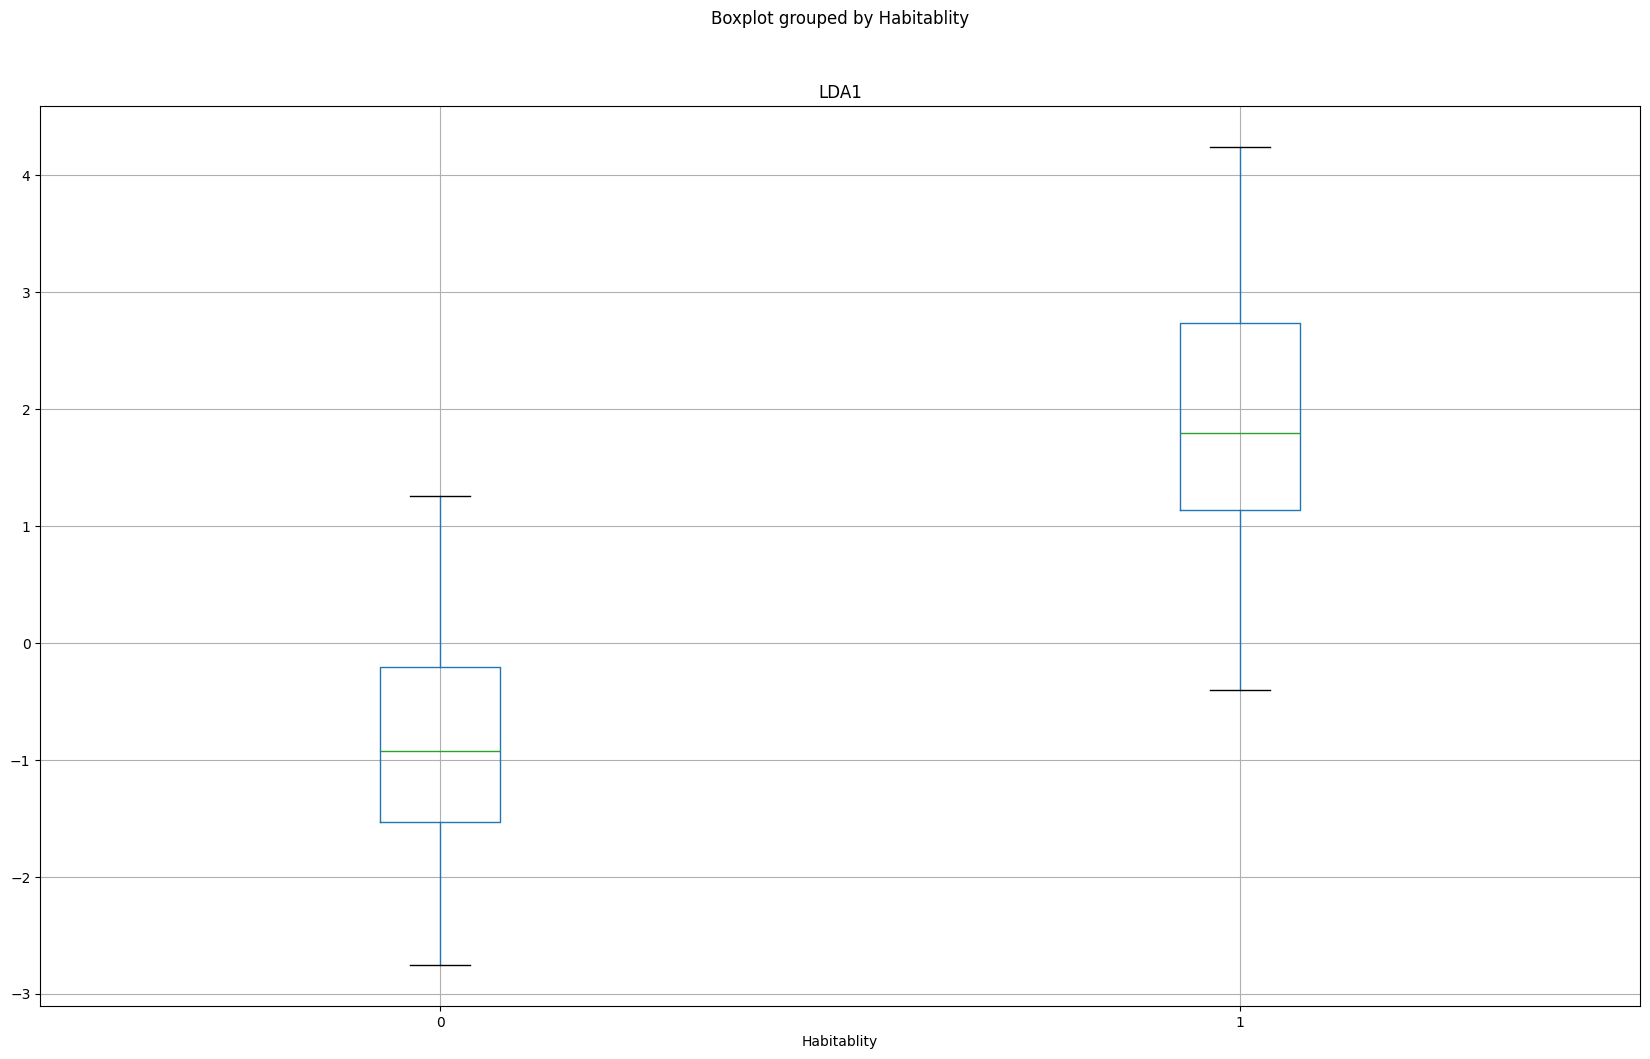

In [69]:
fig, axs = plt.subplots(1, 1, figsize=(20, 12), sharey=False)
boxplot = df_lda.boxplot(column=['LDA1'], by = 'Habitablity', ax=axs, showfliers=False) # Create boxplots for the LDA transformed data grouped by habitability

In [70]:
import plotly.express as px

In [71]:
fig = px.histogram(df_lda, x='LDA1', color='Habitablity', barmode='overlay', nbins=50, title='Distribution of LDA1 by Habitability')
fig.update_traces(opacity=0.75) # Set the opacity of the bars for better visibility
fig.show() # Display the histogram

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        41
           1       1.00      0.80      0.89        10

    accuracy                           0.96        51
   macro avg       0.98      0.90      0.93        51
weighted avg       0.96      0.96      0.96        51



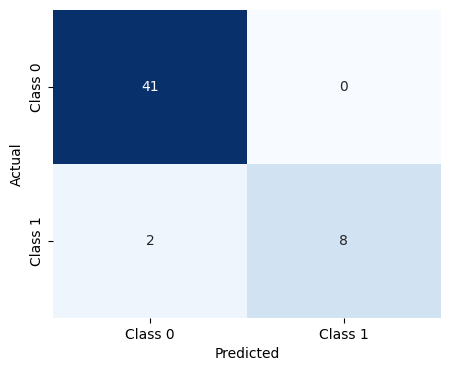

In [72]:
y_pred_lda = lda.predict(X_test_lda) # Predict the stellar type for the test set using LDA

print(classification_report(y_test_lda, y_pred_lda)) # Print the classification report

cm = confusion_matrix(y_test_lda, y_pred_lda)
class_names = ["Class 0", "Class 1"]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot a pretty heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Quadratic discriminant analysis

In [73]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

In [74]:
scaleStandard = StandardScaler() # Create a StandardScaler object to standardize the features
X = df2.iloc[:, 1:9].values # Select the planetary parameters for PCA
y = df2.iloc[:, 30].values # Select the stellar type for PCA

X = scaleStandard.fit_transform(X) # Fit the scaler to the training data and transform it
X_train_qda, X_test_qda, y_train_qda, y_test_qda = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets
X_train_qda = pd.DataFrame(X_train_qda, columns=df2.columns[1:9]) # Convert the scaled training data back to a DataFrame
X_test_qda = pd.DataFrame(X_test_qda, columns=df2.columns[1:9]) # Convert the scaled testing data back to a DataFrame

X_train_qda.describe().round(3) # Display summary statistics of the scaled training data

,P_MASS,P_RADIUS,P_PERIOD,P_GRAVITY,P_DENSITY,P_DISTANCE,P_FLUX,P_TEMP_EQUIL
count,201.000,201.000,201.000,201.000,201.000,201.000,201.000,201.000
mean,-0.036,-0.107,-0.054,0.032,0.041,-0.062,0.009,-0.002
std,1.043,0.915,0.957,1.093,1.079,0.944,1.019,1.024
min,-0.952,-1.579,-0.807,-0.440,-0.497,-1.051,-1.453,-2.300
25%,-0.590,-0.811,-0.668,-0.213,-0.317,-0.778,-0.775,-0.682
50%,-0.229,-0.144,-0.462,-0.172,-0.179,-0.437,-0.197,0.049
75%,0.155,0.498,0.343,-0.122,0.044,0.546,0.642,0.747
max,9.698,3.078,5.262,8.609,8.947,3.883,3.082,2.077


              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       0.83      1.00      0.91        10

    accuracy                           0.96        51
   macro avg       0.92      0.98      0.94        51
weighted avg       0.97      0.96      0.96        51



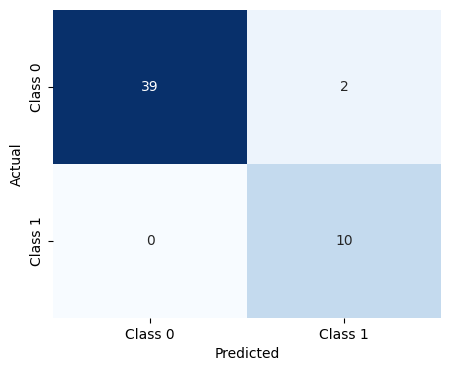

In [75]:
qda = QDA() # Create an QDA object that retains 1 component
X_qda = qda.fit(X_train_qda, y_train_qda) # Fit QDA to the scaled training data and transform it to 1 component

y_pred_qda = qda.predict(X_test_qda) # Predict the stellar type for the test set using QDA

print(classification_report(y_test_qda, y_pred_qda)) # Print the classification report

cm = confusion_matrix(y_test_qda, y_pred_qda)
class_names = ["Class 0", "Class 1"]
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot a pretty heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Checking covariance of classes

In [76]:
hab_df = df2[df2['P_HABITABLE'] == 1]
Nhab_df = df2[df2['P_HABITABLE'] == 0]

hab_df = hab_df[['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL']]
Nhab_df = Nhab_df[['P_MASS', 'P_GRAVITY', 'P_RADIUS', 'P_PERIOD', 'P_DENSITY', 'P_DISTANCE', 'P_FLUX', 'P_TEMP_EQUIL']]

hab_cov = hab_df.cov() # Calculate the covariance matrix for habitable planets
Nhab_cov = Nhab_df.cov() # Calculate the covariance matrix for non-habitable planets

cov_comp = hab_cov - Nhab_cov

print(cov_comp)

                 P_MASS  P_GRAVITY   P_RADIUS     P_PERIOD  P_DENSITY  \
P_MASS        -3.587708  11.653711  -2.841823   -39.926397   9.349135   
P_GRAVITY     11.653711   6.544527   0.059887    68.134881   4.682844   
P_RADIUS      -2.841823   0.059887  -0.549567   -39.080035   0.091127   
P_PERIOD     -39.926397  68.134881 -39.080035 -6073.637927  49.721035   
P_DENSITY      9.349135   4.682844   0.091127    49.721035   3.284858   
P_DISTANCE    -0.104879   0.174463  -0.102135   -12.215766   0.125795   
P_FLUX         2.430147  -0.394121   0.717530    79.343951  -0.433966   
P_TEMP_EQUIL  98.841244 -13.849145  27.448336  3308.524199 -15.651005   

              P_DISTANCE     P_FLUX  P_TEMP_EQUIL  
P_MASS         -0.104879   2.430147     98.841244  
P_GRAVITY       0.174463  -0.394121    -13.849145  
P_RADIUS       -0.102135   0.717530     27.448336  
P_PERIOD      -12.215766  79.343951   3308.524199  
P_DENSITY       0.125795  -0.433966    -15.651005  
P_DISTANCE     -0.024967   0.2